In [1]:
import matplotlib.pyplot as plt
import locomotif.loco as loco
from matplotlib import cm

from sub_tsmd import plot_motif_sets, load_test

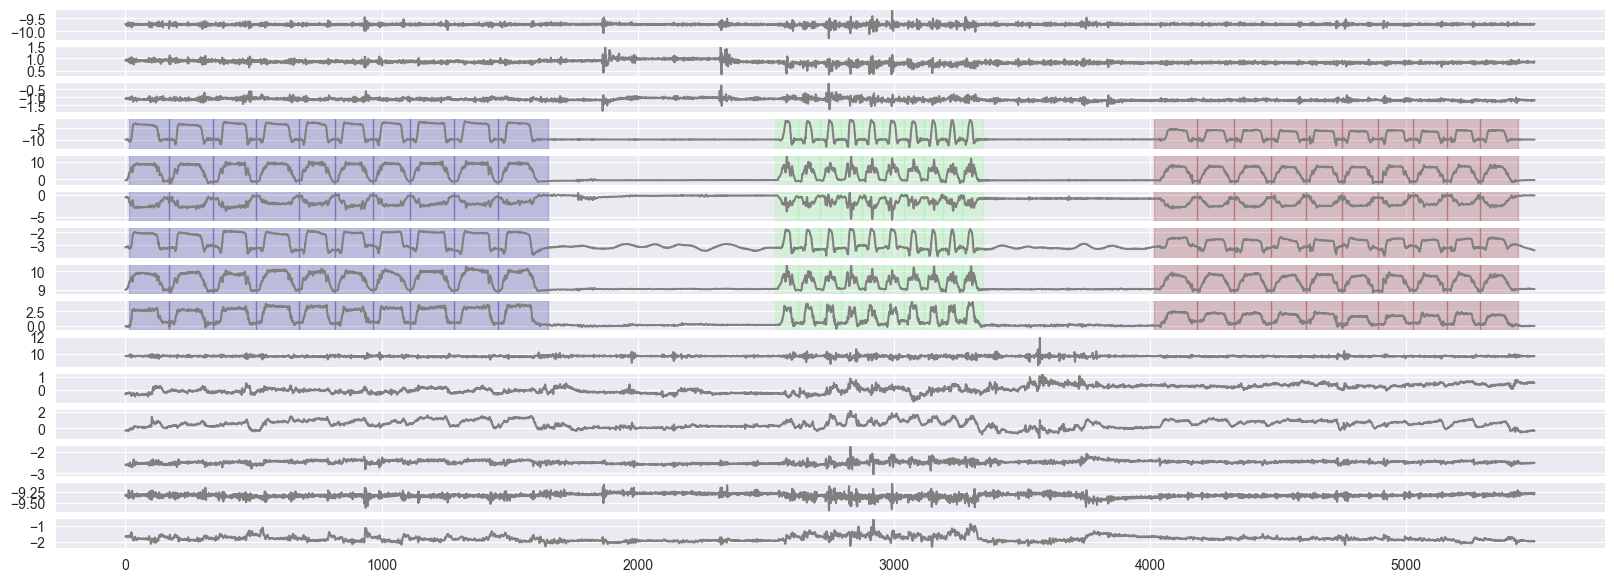

In [2]:
[X, *_], [y, *_] = load_test("../data/physical-therapy/e1")
plot_motif_sets(X, y);

In [3]:
# Adapted from https://github.com/ML-KULeuven/locomotif/blob/main/physiotherapy-use-case/apply_locomotif_physiotherapy.ipynb, but adjusted apply_locomotif_physiotherapy to take the mask as input instead of computing it in the function. 

def get_idle_mask(ts, window_size, threshold):
    if window_size % 2 == 0:
        window_size += 1
    
    n, _ = ts.shape    
    idle = np.full(n, False)
    
    half_window = window_size // 2
    for center in range(half_window, n-half_window):
        window_start = center-half_window
        window_end   = center+half_window+1
        if np.all(np.var(ts[window_start:window_end, :], axis=0) < threshold):
            idle[window_start:window_end] = True
    return idle

def get_start_mask(ts, idle_mask, quantile):    
    # mean of the idle values
    idle_mean  = np.mean(ts[idle_mask, :], axis=0)
    
    # determine the distance threshold
    distances          = np.sum((ts[~idle_mask] - idle_mean) ** 2, axis=1)
    distance_threshold = np.quantile(distances, quantile)

    # construct the start mask
    start_mask = (np.sum((ts - idle_mean) ** 2, axis=1) <= distance_threshold)
    start_mask[idle_mask] = False
    return start_mask.astype(bool)


def apply_locomotif_physiotherapy(ts, l_min, l_max, rho, nb_motifs, overlap=0.25, warping=True, start_mask=None, end_mask=None):   
    ts = ts.astype(np.float32)
    n, D = ts.shape
    
    gamma = np.ones(D, dtype=np.float64)
    ssm = loco.similarity_matrix_ndim(ts, ts, gamma=gamma, only_triu=False)

    # Determine tau based on the non-idle samples
    ssm[np.tril_indices(len(ssm), k=-1)] = np.nan
    tau = np.nanquantile(ssm[~idle_mask, :][:, ~idle_mask], rho, axis=None)
    print(tau)

    # Apply LoCoMotif
    lcm = locomotif.LoCoMotif(ts=ts, gamma=gamma, tau=tau, delta_a=2*tau, delta_m=0.5, l_min=l_min, l_max=l_max)
    lcm.find_best_paths(vwidth=l_min // 2)
    motif_sets = []
    for repr, motif_set, _ in lcm.find_best_motif_sets(nb=nb_motifs, overlap=overlap, start_mask=start_mask, end_mask=end_mask):
        motif_sets.append((repr, motif_set))
    return lcm, motif_sets

In [4]:
import numpy as np
import pandas as pd
from locomotif import locomotif

from sub_tsmd._sub_tsmd import apply_sub_tsmd
from sub_tsmd._SubspaceMotifSet import SubspaceMotifSet


class SubTSMD:
    """
    A class to apply SubTSMD on a time series, in which the motifs in
    each attribute are discovered using LoCoMotif.
    """

    # SubTSMD parameters
    delta: float
    linkage: str
    # LoCoMotif parameters
    l_min: int
    l_max: int
    rho: float | None
    max_number_motif_sets: int | None
    warping: bool
    overlap: float

    def __init__(
        self,
        l_min: int,
        l_max: int,
        delta: float = 0.5,
        linkage: str = "average",
        rho: float = None,
        max_number_motif_sets: float = None,
        warping: bool = True,
        overlap: float = 0.0,
    ):
        assert (
            0.5 <= delta <= 1
        ), f"Invalid delta given: {delta}, must be in the interval [0.5, 1]."
        assert linkage in [
            "complete",
            "average",
        ], f"Invalid linkage method given: '{linkage}', valid options are 'complete' or 'average'."
        assert l_min > 0, f"Invalid l_min given: {l_min}, should be larger than 0. "
        assert (
            l_max >= l_min
        ), f"Invalid l_max given: {l_max}, should be equal to or larger than l_min (={l_min})."
        assert (
            rho is None or 0 <= rho <= 1
        ), f"Invalid rho given: {rho}, should be None or in the interval [0, 1]."
        assert (
            max_number_motif_sets is None or max_number_motif_sets > 0
        ), f"Invalid max_number_motif_sets given: {max_number_motif_sets}, should be None or larger than 0."

        self.delta = delta
        self.linkage = linkage
        self.l_min = l_min
        self.l_max = l_max
        self.rho = rho
        self.max_number_motif_sets = max_number_motif_sets
        self.warping = warping
        self.overlap = overlap

    def apply(
        self,
        X: np.ndarray | pd.DataFrame,
        inclusion_constraint: list[str] | list[int] = None,
        exclusion_constraint: list[str] | list[int] = None,
        size_constraint: int = 1,
        co_occurrence_constraint: list[list[str] | list[int]] = None,
        start_mask: np.array = None,
        end_mask: np.array = None,
    ) -> list[SubspaceMotifSet]:
        # Mine motifs in the attributes independently using LoCoMotif
        independent_motif_sets = []
        all_masks = _get_motif_discovery_masks(
            X=X,
            inclusion_constraint=inclusion_constraint,
            exclusion_constraint=exclusion_constraint,
            co_occurrence_constraint=co_occurrence_constraint,
        )
        for mask in all_masks:
            _, motif_sets = apply_locomotif_physiotherapy(
                X[:, mask], 
                l_min=self.l_min, 
                l_max=self.l_max, 
                rho=self.rho, 
                nb_motifs=self.max_number_motif_sets, 
                overlap=self.overlap, 
                warping=self.warping,
                start_mask=start_mask.copy() if start_mask is not None else None,
                end_mask=end_mask.copy() if end_mask is not None else None,
            )

            # Format the motif sets
            independent_motif_sets.append(
                [
                    (
                        mask,
                        np.repeat(
                            np.array(motif_set).reshape(len(motif_set), 2, 1),
                            mask.sum(),
                            axis=-1,
                        ),
                    )
                    for (_, motif_set) in motif_sets
                ]
            )

        # Replace the indices from LoCoMotif by time indices
        independent_motif_sets = _replace_indices_by_time_index(
            independent_motif_sets, X
        )

        # Apply SubTSMD
        inclusion_constraint_set = (
            inclusion_constraint is not None and len(inclusion_constraint) >= 1
        )
        subspace_motif_sets = apply_sub_tsmd(
            independent_motif_sets,
            delta=self.delta,
            linkage=self.linkage,
            inclusion_constraint_set=inclusion_constraint_set,
        )

        # Return the motif sets that satisfy the size constraint
        return [
            SubspaceMotifSet.from_arrays(motif_set)
            for motif_set in subspace_motif_sets
            if motif_set[0].sum() >= size_constraint
        ]


def _z_normalize(X: np.array) -> np.array:
    return (X - X.mean(axis=0)) / X.std(axis=0)


def _get_motif_discovery_masks(
    X: np.ndarray | pd.DataFrame,
    inclusion_constraint: list[str] | list[int] = None,
    exclusion_constraint: list[str] | list[int] = None,
    co_occurrence_constraint: list[list[str] | list[int]] = None,
) -> list[np.ndarray]:
    used_attributes = np.zeros(shape=X.shape[1], dtype=bool)
    masks = []

    def all_of_type(to_check, of_type):
        return all(map(lambda x: isinstance(x, of_type), to_check))

    def translate_to_integers(constraint_to_translate, columns_list):
        if all_of_type(constraint_to_translate, int):
            return [columns_list.index(col) for col in constraint_to_translate]
        else:
            return constraint_to_translate

    all_constraints = []
    if inclusion_constraint is not None:
        all_constraints.append(inclusion_constraint)
    if exclusion_constraint is not None:
        all_constraints.append(exclusion_constraint)
    if co_occurrence_constraint is not None:
        all_constraints.extend(co_occurrence_constraint)

    if isinstance(X, pd.DataFrame):
        # Check if constraints are correctly formatted
        for constraint in all_constraints:
            all_string = all_of_type(constraint, str)
            all_int = all_of_type(constraint, int)
            if not (all_string or all_int):
                raise ValueError(
                    f"If a pandas dataframe is given, the constraints should be either all integers or all strings! Received: {constraint}"
                )
            if all_string and any(value not in X.columns for value in constraint):
                raise ValueError(
                    f"If a pandas dataframe is given, all string constraints should be a column! Received: {constraint}"
                )
            if all_int and max(constraint) >= X.shape[1]:
                raise ValueError(
                    f"If a pandas dataframe is given, the attribute constraint index must be smaller than {X.shape[1]} (zero-indexed)! Received: {constraint}"
                )

        # Translate the constraints to integers
        columns = list(X.columns)
        if inclusion_constraint is not None:
            inclusion_constraint = translate_to_integers(inclusion_constraint, columns)
        if exclusion_constraint is not None:
            exclusion_constraint = translate_to_integers(exclusion_constraint, columns)
        if co_occurrence_constraint is not None:
            co_occurrence_constraint = [
                translate_to_integers(constraint, columns)
                for constraint in co_occurrence_constraint
            ]

    else:  # X is a numpy array
        for constraint in all_constraints:
            if not all_of_type(constraint, int):
                raise ValueError(
                    f"If a numpy array is given, the constraints should exist of only integers! Received: {constraint}"
                )
            if max(constraint) >= X.shape[1]:
                raise ValueError(
                    f"If a numpy array is given, the attribute constraint index must be smaller than {X.shape[1]} (zero-indexed)! Received: {constraint}"
                )

    if inclusion_constraint is not None:
        new_mask = np.zeros_like(used_attributes)
        new_mask[inclusion_constraint] = True
        masks.append(new_mask)

    if exclusion_constraint is not None:
        used_attributes[exclusion_constraint] = True

    if co_occurrence_constraint is not None:
        for constraint in co_occurrence_constraint:
            new_mask = np.zeros_like(used_attributes)
            new_mask[constraint] = True
            masks.append(new_mask)
            used_attributes[constraint] = True

    # Add the remaining attributes
    for i, used in enumerate(used_attributes):
        if not used:
            new_mask = np.zeros_like(used_attributes)
            new_mask[i] = True
            masks.append(new_mask)

    # Return the masks
    return masks


def _replace_indices_by_time_index(
    independent_motif_sets: list[list[(np.array, np.ndarray)]],
    X: np.ndarray | pd.DataFrame,
) -> list[list[(np.array, np.ndarray)]]:
    if isinstance(X, pd.DataFrame):
        return [
            [
                (
                    mask,
                    X.index.values[motif_set],
                )  # Reindex based on the index of the dataframe
                for mask, motif_set in motif_sets
            ]
            for motif_sets in independent_motif_sets
        ]

    else:
        return independent_motif_sets

0.00092864386
0.9935413
0.00092864386
0.6809944
0.8636489
0.98828435


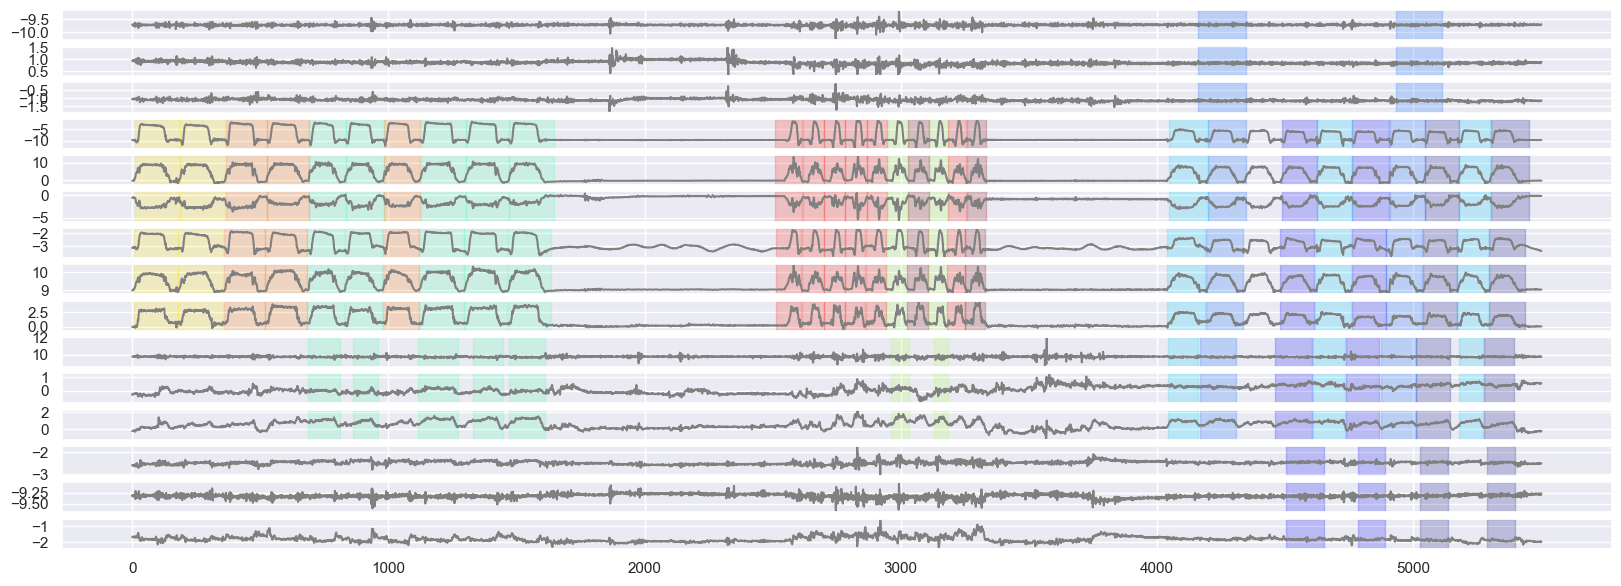

In [13]:
idle_mask  = get_idle_mask(X[:, [3, 4, 5]], 260, 0.005)
start_mask = get_start_mask(X[:, [3, 4, 5]], idle_mask, 0.33)
end_mask   = start_mask

constraints = {
    "inclusion_constraint": [3, 4, 5],
    "co_occurrence_constraint": [[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11], [12, 13, 14]],
    "start_mask": start_mask,
    "end_mask": end_mask
}
sub_tsmd = SubTSMD(50, 300, delta=0.5, rho=0.75, overlap=0.0)
y_pred = sub_tsmd.apply(X, **constraints)
plot_motif_sets(X, y_pred);

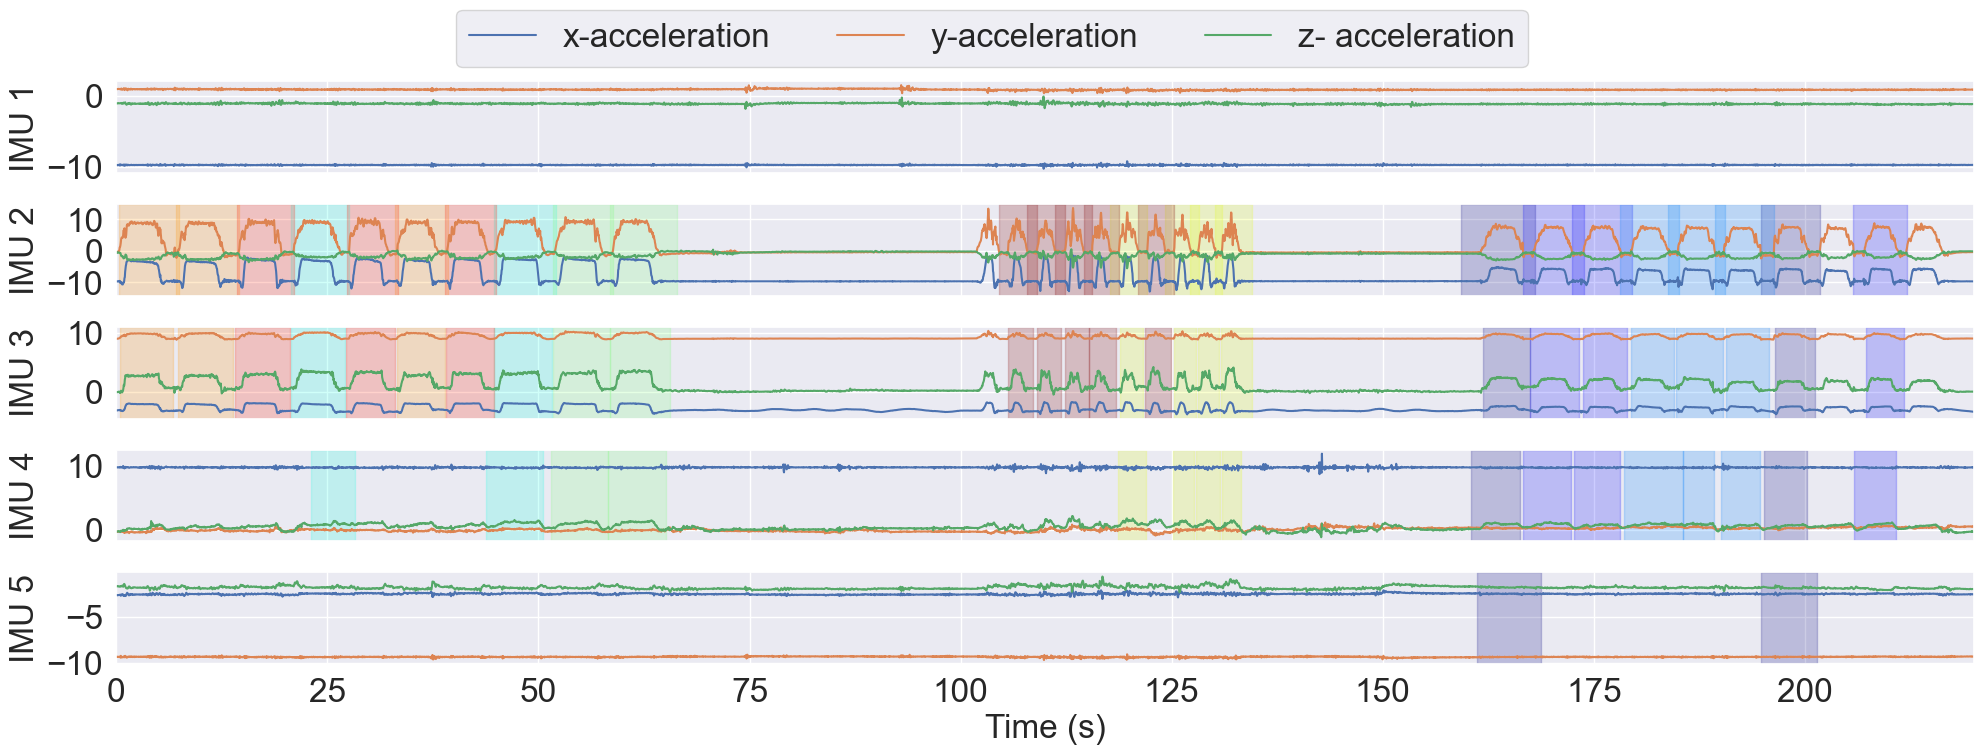

In [11]:
import seaborn as sns
sns.set_theme()

fontsize = 24

fig, axs = plt.subplots(5, 1, figsize=(20, 7), sharex='all')
color_cycle = [cm.jet(x) for x in np.linspace(0.0, 1.0, len(y_pred))]

t = np.arange(X.shape[0]) / 25  # sampling rate: 25Hz

for i in range(5):
    axs[i].set_ylabel(f'IMU {i+1}', fontsize=fontsize)
    axs[i].plot(t, X[:, [3*i, 3*i+1, 3*i+2]])
    axs[i].tick_params(axis='both', which='major', labelsize=fontsize)
    for j, motif_set in enumerate(y_pred):
        if motif_set.mask[i*3]:
            for motif in motif_set.to_motifs:
                s = t[int(min([motif.start(3*i), motif.start(3*i+1), motif.start(3*i+2)]))]
                e = t[int(max([motif.end(3*i), motif.end(3*i+1), motif.end(3*i+2)]))]
                axs[i].axvspan(s, e, color=color_cycle[j], alpha=0.2)

axs[-1].set_xlabel('Time (s)', fontsize=fontsize)
axs[-1].set_xlim(t[0], t[-1])

fig.legend(['x-acceleration', 'y-acceleration', 'z- acceleration'], loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3, fontsize=fontsize)

fig.tight_layout()
fig.align_ylabels()
fig.savefig('figures-paper/fig-physio.png', bbox_inches='tight')